C:\Users\Ifcmc\AppData\Local\Temp\ipykernel_17980\686461706.py:76: UserWarning: Glyph 127464 (\N{REGIONAL INDICATOR SYMBOL LETTER C}) missing from current font.
  plt.tight_layout()
C:\Users\Ifcmc\AppData\Local\Temp\ipykernel_17980\686461706.py:76: UserWarning: Glyph 127473 (\N{REGIONAL INDICATOR SYMBOL LETTER L}) missing from current font.
  plt.tight_layout()
C:\Users\Ifcmc\AppData\Local\Temp\ipykernel_17980\686461706.py:77: UserWarning: Glyph 127464 (\N{REGIONAL INDICATOR SYMBOL LETTER C}) missing from current font.
  plt.savefig('grafico_pib_suicidio_vibrante.png', dpi=300)
C:\Users\Ifcmc\AppData\Local\Temp\ipykernel_17980\686461706.py:77: UserWarning: Glyph 127473 (\N{REGIONAL INDICATOR SYMBOL LETTER L}) missing from current font.
  plt.savefig('grafico_pib_suicidio_vibrante.png', dpi=300)
c:\Users\Ifcmc\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127464 (\N{REGIONAL INDICATOR SYMBOL LETTER C}) missing from current font.
  fig.canvas.print_figure

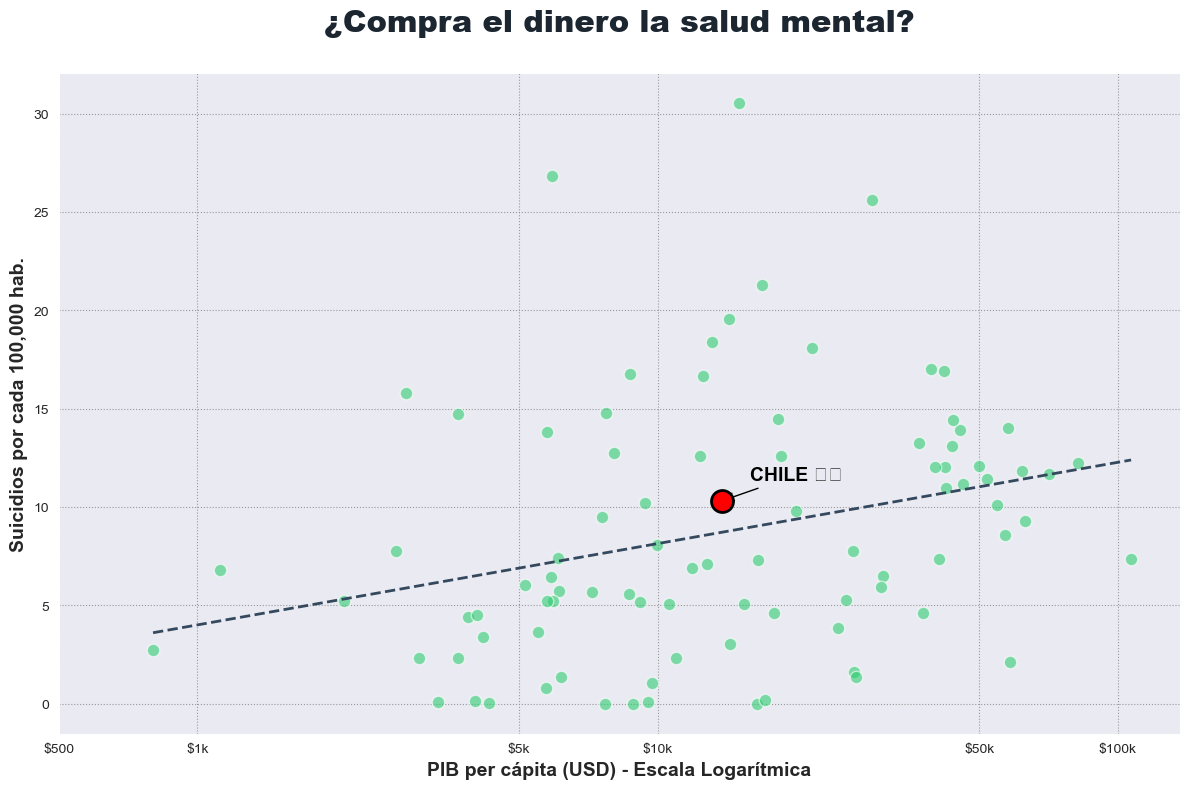

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Estilo base limpio
plt.style.use('seaborn-v0_8-whitegrid')

# Cargar datos
df = pd.read_csv("suicide_rates_1990-2022.csv")

# Filtrar año
df = df[df["Year"] == 2020]

# Limpiar
df = df.dropna(subset=["GDPPerCapita", "DeathRatePer100K", "RegionName"])

# Figura
plt.figure(figsize=(11, 6))

# Colores por continente
colors = {
    "Africa": "#e41a1c",      # rojo fuerte
    "Americas": "#7cc4ff",    # azul fuerte
    "Asia": "#3ceb36",        # verde fuerte 
    "Europe": "#ff7f00",      # naranja fuerte
    "Oceania": "#e540ff"      # morado fuerte
}

# Scatter por continente
for region in df["RegionName"].unique():
    subset = df[df["RegionName"] == region]
    
    plt.scatter(
        subset["GDPPerCapita"],
        subset["DeathRatePer100K"],
        label=region,
        color=colors.get(region, "#EEF741"),
        alpha=0.85,
        edgecolor="black",
        linewidth=0.5,
        s=60
    )

# Escala logarítmica
plt.xscale("log")

# 🔥 TICKS PERSONALIZADOS (LO IMPORTANTE)
ticks = [1000, 5000, 10000, 50000, 100000]
labels = ["$1k", "$5k", "$10k", "$50k", "$100k"]
plt.xticks(ticks, labels)

# Línea de tendencia
x = df["GDPPerCapita"]
y = df["DeathRatePer100K"]

coef = np.polyfit(np.log(x), y, 1)
trend = np.poly1d(coef)

x_line = np.linspace(x.min(), x.max(), 100)
y_line = trend(np.log(x_line))

plt.plot(
    x_line, y_line,
    color="black",
    linestyle="--",
    linewidth=2,
    label="Tendencia global"
)

# Títulos
plt.title(
    "Relación entre PIB per cápita y tasa de suicidio por continente (2020)",
    fontsize=16,
    pad=15
)

plt.xlabel("PIB per cápita (USD, escala logarítmica)", fontsize=12)
plt.ylabel("Tasa de suicidio por 100.000 habitantes", fontsize=12)

# Leyenda
plt.legend(title="Continente", frameon=True)

# Estética
plt.grid(True, linestyle="--", alpha=0.3)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_facecolor("#f5f5f5")

# Guardar
plt.savefig("grafico.png", dpi=300, bbox_inches="tight")

# Mostrar
plt.show()